# Banking Customer Risk Analysis
## Loan Default Prediction using Give Me Some Credit Dataset

**Author:** Rishav Raj  
**Dataset:** [Give Me Some Credit — Kaggle](https://www.kaggle.com/competitions/GiveMeSomeCredit/data)   
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

---


## 1. Project Overview

The goal of this project is to analyze borrower data and understand what factors lead to loan defaults.

The dataset comes from a Kaggle competition called **"Give Me Some Credit"** which contains financial information of ~150,000 borrowers. The target variable is whether a borrower experienced serious delinquency in 2 years.

**What I'm trying to answer:**
- Which borrower characteristics are most associated with defaults?
- Can we segment borrowers into meaningful risk groups?
- What patterns exist across age, income, and delinquency history?


## 2. Setup and Data Loading

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
%pip install scipy
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

print("Libraries loaded successfully")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully


In [24]:
df = pd.read_csv('/Users/rishavraj/Desktop/Banking Analysis Project/cs-training.csv', index_col=0)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())


Dataset shape: (150000, 11)

Column names:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


## 3. Initial Data Exploration

Let's get a basic understanding of the dataset before doing any cleaning.


In [25]:
# Basic info
print("Dataset Info:")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")


Dataset Info:
Rows: 150,000
Columns: 11
Memory usage: 13.20 MB


In [26]:
# Check data types and missing values
missing = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing)


                                        dtype  missing_count  missing_pct
SeriousDlqin2yrs                        int64              0        0.000
RevolvingUtilizationOfUnsecuredLines  float64              0        0.000
age                                     int64              0        0.000
NumberOfTime30-59DaysPastDueNotWorse    int64              0        0.000
DebtRatio                             float64              0        0.000
MonthlyIncome                         float64          29731       19.820
NumberOfOpenCreditLinesAndLoans         int64              0        0.000
NumberOfTimes90DaysLate                 int64              0        0.000
NumberRealEstateLoansOrLines            int64              0        0.000
NumberOfTime60-89DaysPastDueNotWorse    int64              0        0.000
NumberOfDependents                    float64           3924        2.620


In [27]:
# Target variable distribution
target_counts = df['SeriousDlqin2yrs'].value_counts()
print("Target Variable Distribution:")
print(f"  No Default (0): {target_counts[0]:,}  ({target_counts[0]/len(df):.2%})")
print(f"  Default    (1): {target_counts[1]:,}  ({target_counts[1]/len(df):.2%})")
print(f"\nClass imbalance ratio: 1:{target_counts[0]//target_counts[1]}")


Target Variable Distribution:
  No Default (0): 139,974  (93.32%)
  Default    (1): 10,026  (6.68%)

Class imbalance ratio: 1:13


In [28]:
# Summary statistics split by default status
numeric_cols = df.select_dtypes(include=np.number).columns.drop('SeriousDlqin2yrs').tolist()
summary = df.groupby('SeriousDlqin2yrs')[numeric_cols].mean().round(3)
print("Mean values by default status:")
print(summary.T)


Mean values by default status:
SeriousDlqin2yrs                            0        1
RevolvingUtilizationOfUnsecuredLines    6.169    4.367
age                                    52.751   45.927
NumberOfTime30-59DaysPastDueNotWorse    0.280    2.388
DebtRatio                             357.151  295.121
MonthlyIncome                        6747.838 5630.826
NumberOfOpenCreditLinesAndLoans         8.494    7.882
NumberOfTimes90DaysLate                 0.135    2.091
NumberRealEstateLoansOrLines            1.020    0.989
NumberOfTime60-89DaysPastDueNotWorse    0.127    1.828
NumberOfDependents                      0.743    0.948


## 4. Data Cleaning

The dataset has a few known issues:
- `RevolvingUtilizationOfUnsecuredLines` has some values way above 1 (which doesn't make sense for a utilization rate)
- `age` has some entries below 18
- Past-due columns have sentinel values 96 and 98 which are data quality markers, not real counts
- `MonthlyIncome` and `NumberOfDependents` have missing values


In [29]:
df_clean = df.copy()

# Cap revolving utilization at 1.0
n = (df_clean['RevolvingUtilizationOfUnsecuredLines'] > 1.0).sum()
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
print(f"Revolving utilization capped: {n:,} records")

# Remove invalid ages
n = ((df_clean['age'] < 18) | (df_clean['age'] > 100)).sum()
df_clean = df_clean[(df_clean['age'] >= 18) & (df_clean['age'] <= 100)].copy()
print(f"Invalid age rows removed: {n:,}")

# Replace sentinel values with NaN
past_due_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for col in past_due_cols:
    n = df_clean[col].isin([96, 98]).sum()
    df_clean[col] = df_clean[col].replace([96, 98], np.nan)
    print(f"Sentinel values removed from {col}: {n}")

# Cap extreme debt ratios
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(0, 5000)
print("\nDebt ratio capped at 5000")


Revolving utilization capped: 3,321 records
Invalid age rows removed: 14
Sentinel values removed from NumberOfTime30-59DaysPastDueNotWorse: 269
Sentinel values removed from NumberOfTime60-89DaysPastDueNotWorse: 269
Sentinel values removed from NumberOfTimes90DaysLate: 269

Debt ratio capped at 5000


In [30]:
# Impute missing values

# MonthlyIncome: use group median by default status
n = df_clean['MonthlyIncome'].isnull().sum()
group_median = df_clean.groupby('SeriousDlqin2yrs')['MonthlyIncome'].transform('median')
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(group_median)
print(f"MonthlyIncome imputed: {n:,} records (group median)")

# NumberOfDependents: fill with 0 (most likely no dependents)
n = df_clean['NumberOfDependents'].isnull().sum()
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)
print(f"NumberOfDependents imputed: {n:,} records (filled with 0)")

# Past-due sentinel NaNs -> 0
for col in past_due_cols:
    n = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(0)
    print(f"{col} NaNs filled: {n}")

print(f"\nTotal missing values remaining: {df_clean.isnull().sum().sum()}")


MonthlyIncome imputed: 29,724 records (group median)
NumberOfDependents imputed: 3,921 records (filled with 0)
NumberOfTime30-59DaysPastDueNotWorse NaNs filled: 269
NumberOfTime60-89DaysPastDueNotWorse NaNs filled: 269
NumberOfTimes90DaysLate NaNs filled: 269

Total missing values remaining: 0


## 5. Feature Engineering

Creating a few new features that might be useful for analysis.


In [31]:
# Total delinquencies across all buckets
df_clean['TotalDelinquencies'] = (
    df_clean['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_clean['NumberOfTime60-89DaysPastDueNotWorse'] +
    df_clean['NumberOfTimes90DaysLate']
)

# Binary flag: has any delinquency?
df_clean['HasDelinquency'] = (df_clean['TotalDelinquencies'] > 0).astype(int)

# Income per dependent (add 1 to avoid divide by zero)
df_clean['IncomePerDependent'] = df_clean['MonthlyIncome'] / (df_clean['NumberOfDependents'] + 1)

# Age groups
df_clean['AgeBand'] = pd.cut(
    df_clean['age'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

# Utilization tiers
df_clean['UtilizationBand'] = pd.cut(
    df_clean['RevolvingUtilizationOfUnsecuredLines'],
    bins=[-0.001, 0.30, 0.60, 0.80, 1.001],
    labels=['Low (0-30%)', 'Moderate (30-60%)', 'High (60-80%)', 'Critical (80-100%)']
)

# High debt burden flag (CFPB threshold is 43%)
df_clean['HighDebtBurden'] = (df_clean['DebtRatio'] > 0.43).astype(int)

print(f"New features added. Dataset now has {df_clean.shape[1]} columns.")
print(df_clean[['TotalDelinquencies', 'HasDelinquency', 'IncomePerDependent', 'AgeBand', 'UtilizationBand']].head())


New features added. Dataset now has 17 columns.
   TotalDelinquencies  HasDelinquency  IncomePerDependent AgeBand  \
1               2.000               1            3040.000   36-45   
2               0.000               0            1300.000   36-45   
3               2.000               1            3042.000   36-45   
4               0.000               0            3300.000   26-35   
5               1.000               1           63588.000   46-55   

      UtilizationBand  
1       High (60-80%)  
2  Critical (80-100%)  
3       High (60-80%)  
4         Low (0-30%)  
5  Critical (80-100%)  


In [32]:
# Simple credit score proxy (FICO-inspired weights)
# Payment history: 35%, Amounts owed: 30%, Age: 15%, Credit mix: 10%, DTI: 10%

payment_score     = 100 * (1 - df_clean['TotalDelinquencies'].clip(0, 10) / 10)
utilization_score = 100 * (1 - df_clean['RevolvingUtilizationOfUnsecuredLines'])
age_score         = (df_clean['age'] - 18) / 80 * 100
credit_mix_score  = df_clean['NumberOfOpenCreditLinesAndLoans'].clip(0, 20) / 20 * 100
dti_score         = 100 - df_clean['DebtRatio'].clip(0, 1) * 100

raw_score = (
    0.35 * payment_score +
    0.30 * utilization_score +
    0.15 * age_score +
    0.10 * credit_mix_score +
    0.10 * dti_score
)

# Scale to 300-850
s_min, s_max = raw_score.min(), raw_score.max()
df_clean['CreditScore'] = (300 + (raw_score - s_min) / (s_max - s_min) * 550).round(0).astype(int)

# Risk tiers based on score
df_clean['RiskTier'] = pd.cut(
    df_clean['CreditScore'],
    bins=[299, 579, 669, 739, 799, 900],
    labels=['Very Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']
)

print(f"Credit score range: {df_clean['CreditScore'].min()} - {df_clean['CreditScore'].max()}")
print("\nRisk tier distribution:")
print(df_clean['RiskTier'].value_counts())


Credit score range: 300 - 850

Risk tier distribution:
RiskTier
Good           54850
Very Good      41992
Fair           28193
Very Poor      21723
Exceptional     3228
Name: count, dtype: int64


## 6. Exploratory Data Analysis

Let's look at how different variables relate to loan default.


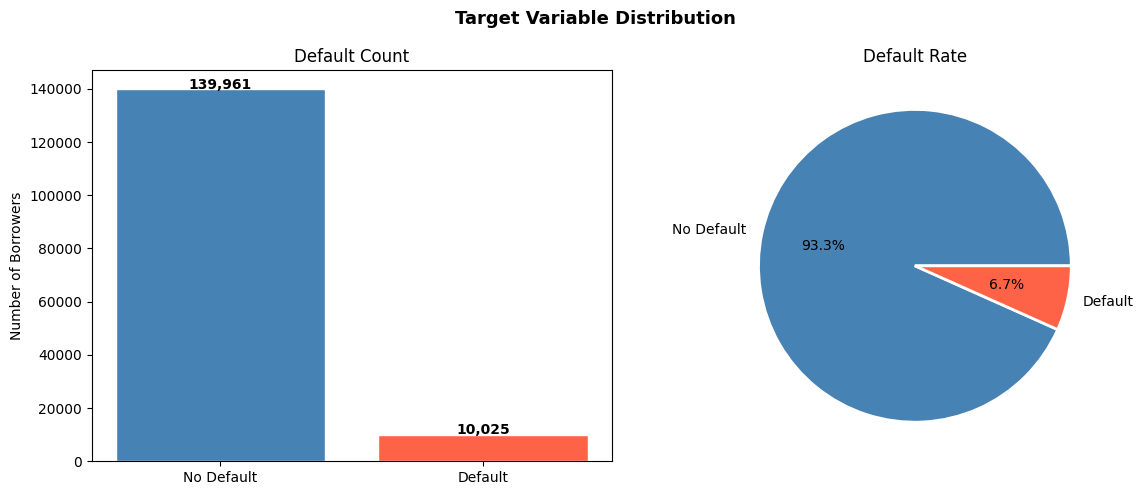

In [33]:
# Default rate overview
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_clean['SeriousDlqin2yrs'].value_counts().sort_index()

# Bar chart
axes[0].bar(['No Default', 'Default'], counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Default Count')
axes[0].set_ylabel('Number of Borrowers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Default', 'Default'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Default Rate')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


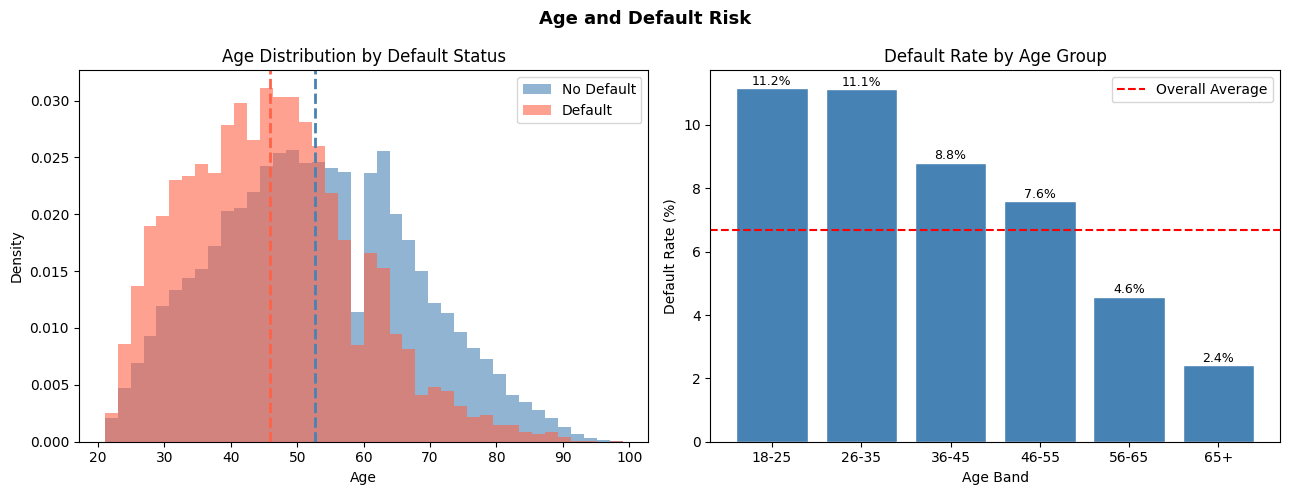

In [34]:
# Age distribution by default status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
for label, color, name in [(0, 'steelblue', 'No Default'), (1, 'tomato', 'Default')]:
    subset = df_clean[df_clean['SeriousDlqin2yrs'] == label]['age']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    axes[0].axvline(subset.mean(), color=color, linestyle='--', linewidth=2)

axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].set_title('Age Distribution by Default Status')
axes[0].legend()

# Default rate by age band
age_default = df_clean.groupby('AgeBand', observed=False)['SeriousDlqin2yrs'].mean() * 100
axes[1].bar(age_default.index, age_default.values, color='steelblue', edgecolor='white')
axes[1].axhline(df_clean['SeriousDlqin2yrs'].mean() * 100, color='red',
                linestyle='--', linewidth=1.5, label='Overall Average')
for i, v in enumerate(age_default.values):
    if not np.isnan(v):
        axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set_xlabel('Age Band')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate by Age Group')
axes[1].legend()

plt.suptitle('Age and Default Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


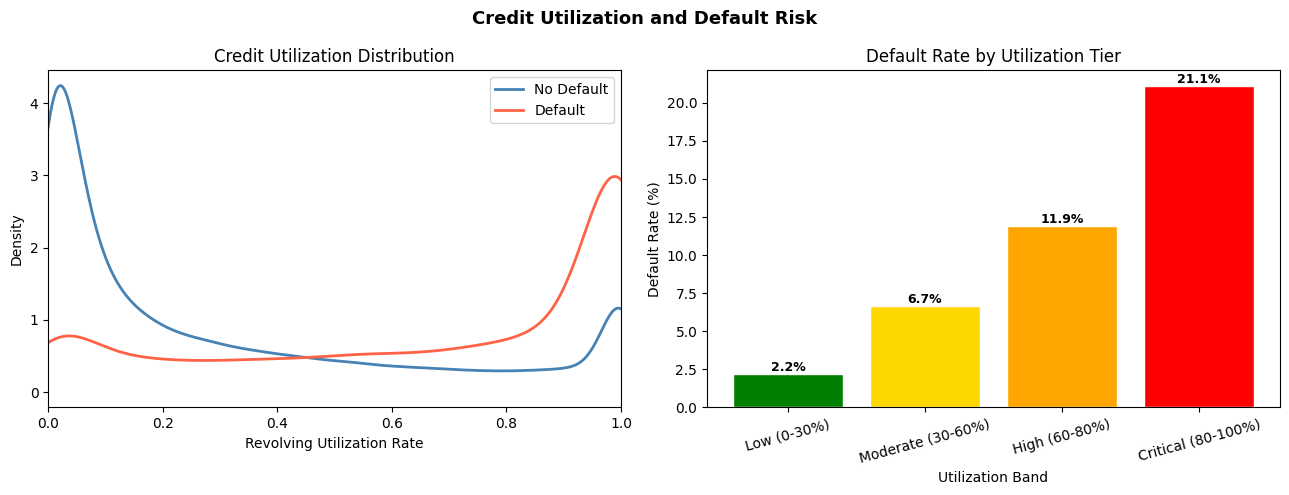

In [35]:
# Credit utilization and default risk
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE plot
for label, color, name in [(0, 'steelblue', 'No Default'), (1, 'tomato', 'Default')]:
    subset = df_clean[df_clean['SeriousDlqin2yrs'] == label]['RevolvingUtilizationOfUnsecuredLines']
    subset.plot.kde(ax=axes[0], color=color, linewidth=2, label=name)

axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Revolving Utilization Rate')
axes[0].set_ylabel('Density')
axes[0].set_title('Credit Utilization Distribution')
axes[0].legend()

# Default rate by utilization band
util_rate = df_clean.groupby('UtilizationBand', observed=False)['SeriousDlqin2yrs'].mean() * 100
axes[1].bar(util_rate.index, util_rate.values,
            color=['green', 'gold', 'orange', 'red'], edgecolor='white')
for i, v in enumerate(util_rate.values):
    if not np.isnan(v):
        axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Utilization Band')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate by Utilization Tier')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Credit Utilization and Default Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


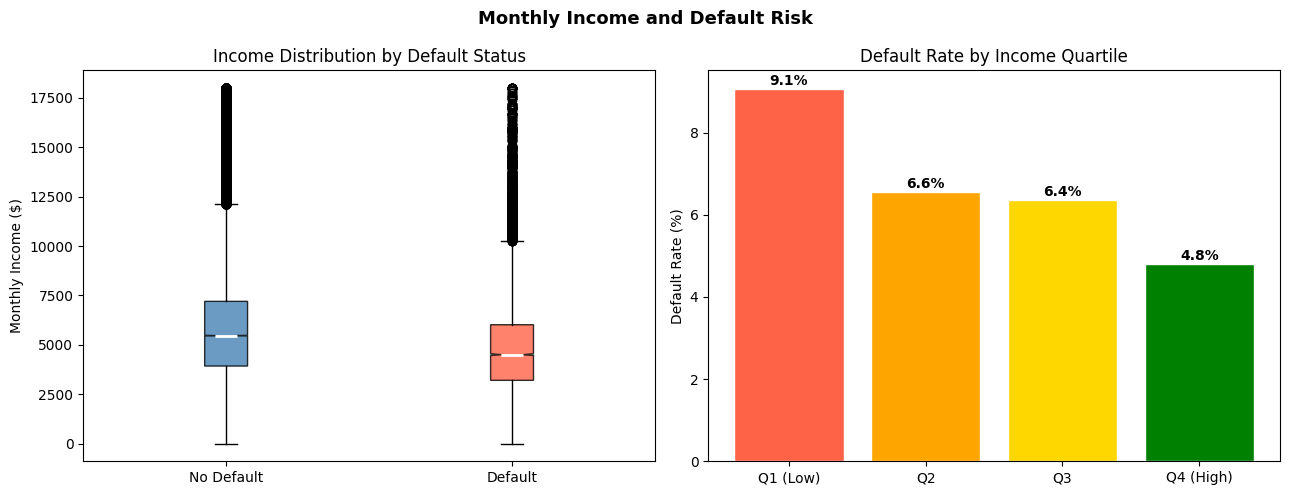

In [36]:
# Monthly income and default risk
income_cap = df_clean['MonthlyIncome'].quantile(0.98)
plot_df = df_clean[df_clean['MonthlyIncome'] <= income_cap].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
groups = [plot_df[plot_df['SeriousDlqin2yrs'] == i]['MonthlyIncome'] for i in [0, 1]]
bp = axes[0].boxplot(groups, labels=['No Default', 'Default'],
                     patch_artist=True, notch=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_ylabel('Monthly Income ($)')
axes[0].set_title('Income Distribution by Default Status')

# Default rate by income quartile
plot_df['IncomeQuartile'] = pd.qcut(
    plot_df['MonthlyIncome'], q=4,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
)
iq_rate = plot_df.groupby('IncomeQuartile', observed=False)['SeriousDlqin2yrs'].mean() * 100
axes[1].bar(iq_rate.index, iq_rate.values,
            color=['tomato', 'orange', 'gold', 'green'], edgecolor='white')
for i, v in enumerate(iq_rate.values):
    if not np.isnan(v):
        axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate by Income Quartile')

plt.suptitle('Monthly Income and Default Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


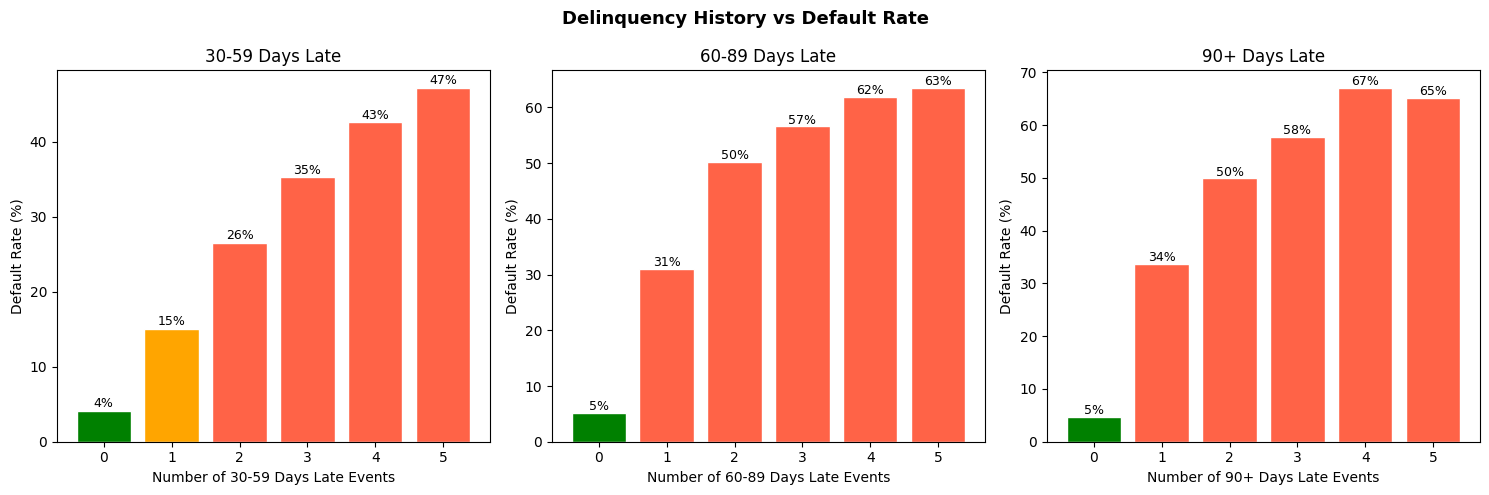

In [37]:
# Delinquency history and default rate
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

delinquency_cols = {
    'NumberOfTime30-59DaysPastDueNotWorse': '30-59 Days Late',
    'NumberOfTime60-89DaysPastDueNotWorse': '60-89 Days Late',
    'NumberOfTimes90DaysLate': '90+ Days Late'
}

for ax, (col, title) in zip(axes, delinquency_cols.items()):
    col_clipped = df_clean[col].clip(0, 5).astype(int)
    rate_df = pd.crosstab(col_clipped, df_clean['SeriousDlqin2yrs'], normalize='index') * 100
    if 1 in rate_df.columns:
        vals = rate_df[1].values
        colors = ['green' if v < 10 else 'orange' if v < 25 else 'tomato' for v in vals]
        ax.bar(rate_df.index, vals, color=colors, edgecolor='white')
        for i, v in enumerate(vals):
            if not np.isnan(v) and v > 0:
                ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=9)
    ax.set_xlabel(f'Number of {title} Events')
    ax.set_ylabel('Default Rate (%)')
    ax.set_title(title)

plt.suptitle('Delinquency History vs Default Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


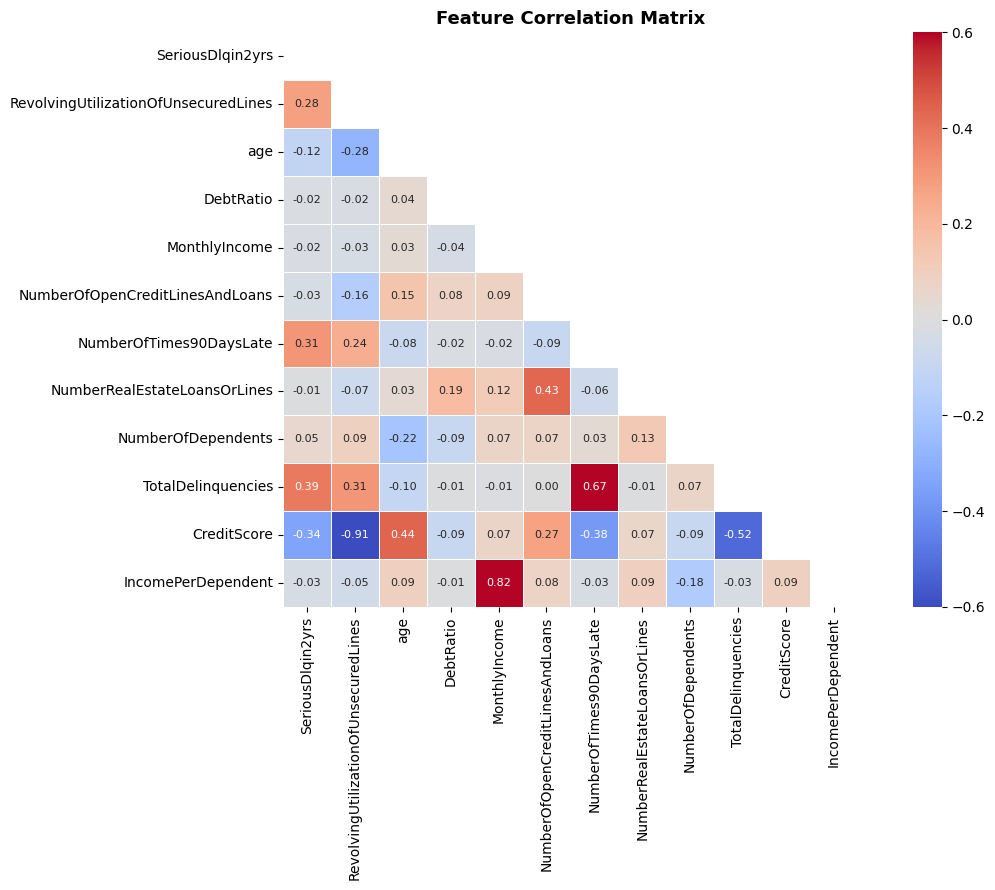

Top features correlated with default:
TotalDelinquencies                     0.389
CreditScore                            0.342
NumberOfTimes90DaysLate                0.312
RevolvingUtilizationOfUnsecuredLines   0.278
age                                    0.115
NumberOfDependents                     0.047
IncomePerDependent                     0.031
NumberOfOpenCreditLinesAndLoans        0.030
Name: SeriousDlqin2yrs, dtype: float64


In [38]:
# Correlation heatmap
numeric_features = [
    'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
    'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfDependents', 'TotalDelinquencies', 'CreditScore', 'IncomePerDependent'
]

corr = df_clean[numeric_features].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    cmap='coolwarm', vmax=0.6, vmin=-0.6, center=0,
    annot=True, fmt='.2f', square=True,
    linewidths=0.5, linecolor='white', ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with target
target_corr = corr['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').abs().sort_values(ascending=False)
print("Top features correlated with default:")
print(target_corr.head(8).round(3))


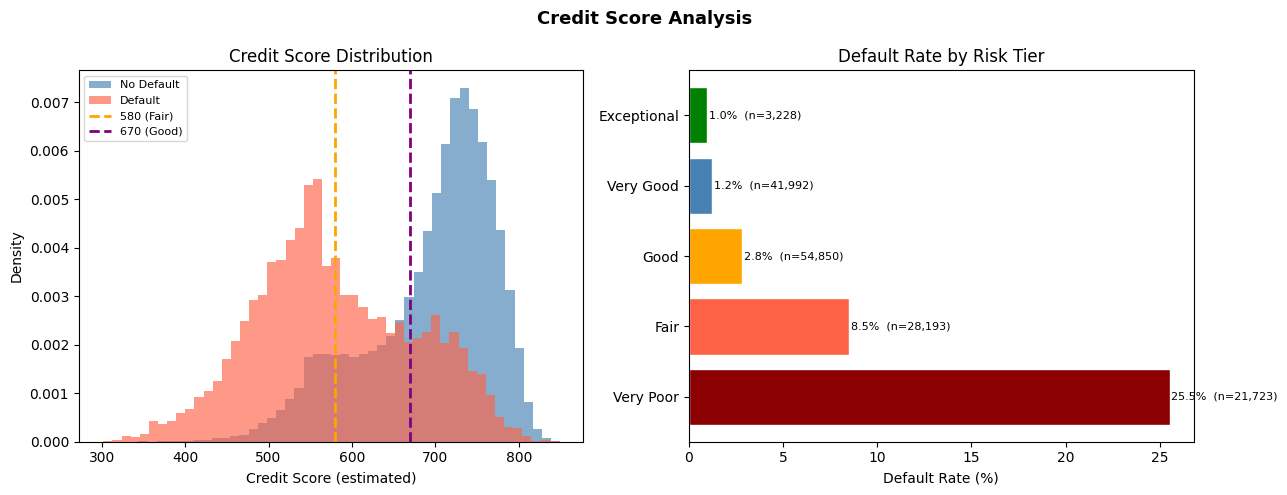

In [39]:
# Credit score distribution and default rate by risk tier
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Score distribution
for label, color, name in [(0, 'steelblue', 'No Default'), (1, 'tomato', 'Default')]:
    axes[0].hist(
        df_clean[df_clean['SeriousDlqin2yrs'] == label]['CreditScore'],
        bins=50, alpha=0.65, color=color, label=name, density=True
    )
axes[0].axvline(580, color='orange', linestyle='--', linewidth=2, label='580 (Fair)')
axes[0].axvline(670, color='purple', linestyle='--', linewidth=2, label='670 (Good)')
axes[0].set_xlabel('Credit Score (estimated)')
axes[0].set_ylabel('Density')
axes[0].set_title('Credit Score Distribution')
axes[0].legend(fontsize=8)

# Default rate by risk tier
tier_rate = df_clean.groupby('RiskTier', observed=False)['SeriousDlqin2yrs'].mean() * 100
tier_counts = df_clean.groupby('RiskTier', observed=False).size()
tier_colors = ['darkred', 'tomato', 'orange', 'steelblue', 'green']
bars = axes[1].barh(tier_rate.index, tier_rate.values, color=tier_colors, edgecolor='white')
for bar, (tier, rate) in zip(bars, tier_rate.items()):
    w = bar.get_width()
    if not np.isnan(w):
        axes[1].text(w + 0.1, bar.get_y() + bar.get_height() / 2,
                     f'{w:.1f}%  (n={tier_counts[tier]:,})', va='center', fontsize=8)
axes[1].set_xlabel('Default Rate (%)')
axes[1].set_title('Default Rate by Risk Tier')

plt.suptitle('Credit Score Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Advanced Analysis

### Risk Matrix

Let's look at how Risk Tier and Credit Utilization Band together affect default rates.


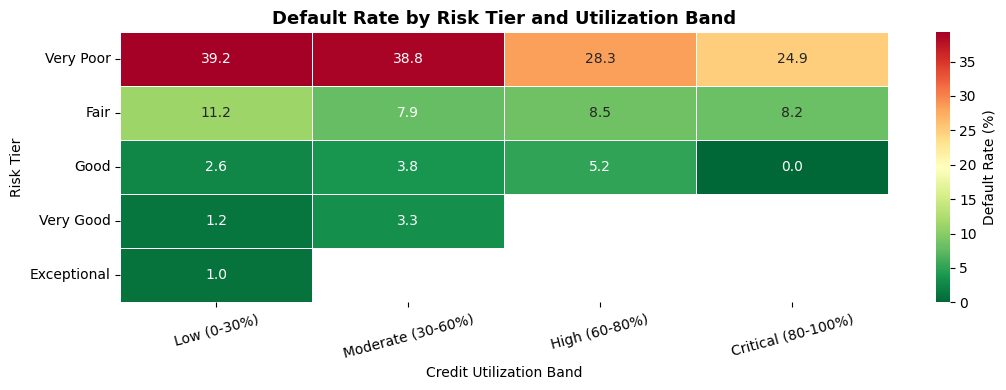

Risk Matrix (% Default Rate):
UtilizationBand  Low (0-30%)  Moderate (30-60%)  High (60-80%)  \
RiskTier                                                         
Very Poor             39.200             38.800         28.300   
Fair                  11.200              7.900          8.500   
Good                   2.600              3.800          5.200   
Very Good              1.200              3.300            NaN   
Exceptional            1.000                NaN            NaN   

UtilizationBand  Critical (80-100%)  
RiskTier                             
Very Poor                    24.900  
Fair                          8.200  
Good                          0.000  
Very Good                       NaN  
Exceptional                     NaN  


In [40]:
# Risk matrix: Risk Tier x Utilization Band
risk_matrix = df_clean.pivot_table(
    values='SeriousDlqin2yrs',
    index='RiskTier',
    columns='UtilizationBand',
    aggfunc='mean',
    observed=False
) * 100

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    risk_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'Default Rate (%)'}
)
ax.set_title('Default Rate by Risk Tier and Utilization Band', fontsize=13, fontweight='bold')
ax.set_xlabel('Credit Utilization Band')
ax.set_ylabel('Risk Tier')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Risk Matrix (% Default Rate):")
print(risk_matrix.round(1))


In [41]:
# Borrower segmentation
def classify_segment(row):
    score = row['CreditScore']
    util  = row['RevolvingUtilizationOfUnsecuredLines']
    delq  = row['TotalDelinquencies']

    if   score >= 740 and util < 0.30 and delq == 0: return 'Premium'
    elif score >= 670 and util < 0.60 and delq <= 1: return 'Standard'
    elif score >= 580 and util < 0.80:               return 'Marginal'
    elif score <  580 and delq >= 2:                 return 'Subprime'
    else:                                            return 'Watch List'

df_clean['Segment'] = df_clean.apply(classify_segment, axis=1)

seg_summary = df_clean.groupby('Segment').agg(
    count        = ('SeriousDlqin2yrs', 'count'),
    default_rate = ('SeriousDlqin2yrs', 'mean'),
    avg_score    = ('CreditScore', 'mean'),
    avg_income   = ('MonthlyIncome', 'mean'),
    avg_util     = ('RevolvingUtilizationOfUnsecuredLines', 'mean')
).sort_values('default_rate')

seg_summary['default_pct'] = (seg_summary['default_rate'] * 100).round(2)
seg_summary['pct_of_portfolio'] = (seg_summary['count'] / len(df_clean) * 100).round(1)

print("Borrower Segments:")
print(seg_summary[['count', 'default_pct', 'pct_of_portfolio', 'avg_score', 'avg_income', 'avg_util']].round(2))


Borrower Segments:
            count  default_pct  pct_of_portfolio  avg_score  avg_income  \
Segment                                                                   
Premium     42797        0.970            28.500    767.870    7628.040   
Standard    55008        2.450            36.700    712.300    6214.060   
Marginal    24710        9.080            16.500    641.140    5987.810   
Watch List  19642       12.880            13.100    563.130    5389.780   
Subprime     7829       44.570             5.200    500.130    5231.330   

            avg_util  
Segment               
Premium        0.050  
Standard       0.150  
Marginal       0.480  
Watch List     0.950  
Subprime       0.900  


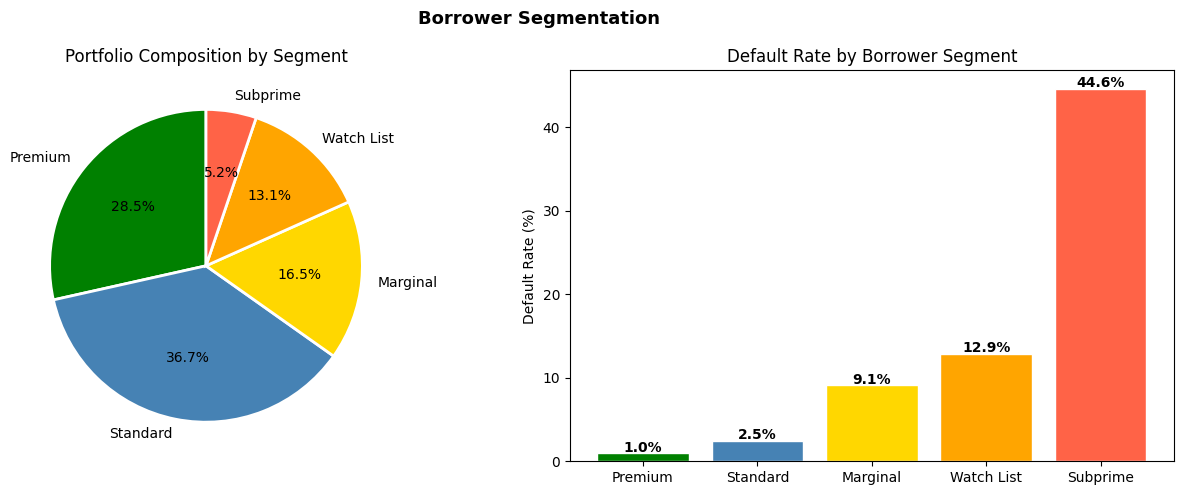

In [42]:
# Segment visualization
seg_order  = ['Premium', 'Standard', 'Marginal', 'Watch List', 'Subprime']
seg_colors = ['green', 'steelblue', 'gold', 'orange', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Portfolio composition
seg_pct = seg_summary.reindex(seg_order)['pct_of_portfolio'].fillna(0)
non_zero = seg_pct > 0
axes[0].pie(
    seg_pct[non_zero], labels=seg_pct[non_zero].index,
    colors=[c for c, nz in zip(seg_colors, non_zero) if nz],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Portfolio Composition by Segment')

# Default rate by segment
seg_def = seg_summary.reindex(seg_order)['default_pct'].fillna(0)
bars = axes[1].bar(seg_def.index, seg_def.values, color=seg_colors, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    if not np.isnan(h) and h >= 0:
        axes[1].text(bar.get_x() + bar.get_width() / 2, h + 0.2,
                     f'{h:.1f}%', ha='center', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate by Borrower Segment')

plt.suptitle('Borrower Segmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Key Findings

Based on the analysis, here are the main takeaways:

**1. Delinquency history is the strongest predictor**  
Even a single 30-59 day late payment significantly increases default probability. Borrowers with 3+ delinquency events show 40-70% default rates compared to the 6.7% baseline.

**2. Credit utilization above 80% is a strong risk signal**  
Borrowers in the Critical utilization tier (80-100%) default at 3-5x the portfolio average. This is consistent with FICO's model where "amounts owed" accounts for 30% of the score.

**3. Younger borrowers (18-35) show higher default rates**  
Likely due to shorter credit history and more income volatility. Not necessarily bad character — just less established financial track record.

**4. A "Danger Zone" exists: Score < 580 AND Utilization > 80%**  
This combination produces very high default rates — multiples above the portfolio average.

**5. Income alone doesn't predict default well**  
A high-income borrower with a high debt ratio can still be risky. The combination of income + debt obligations (DTI) is more informative.

**6. Credit score tiers show a non-linear relationship with default**  
Default rates drop sharply above 580 and flatten above 740. This validates using these thresholds as policy cutpoints.


## 9. Conclusion

This project walked through a complete credit risk analysis pipeline:

- Loaded and cleaned the Give Me Some Credit dataset (150,000 borrower records)
- Handled missing values and data quality issues specific to this dataset
- Engineered features including a FICO-proxy credit score, delinquency aggregates, and utilization tiers
- Explored key risk drivers through visualizations
- Built a simple borrower segmentation model

The analysis shows that default risk is predictable from a combination of delinquency history, credit utilization, and income metrics. A simple rule-based segmentation using these features can already differentiate between Premium borrowers (very low default) and Subprime borrowers (very high default).



---




**Rishav Raj**        
Skills: Python - SQL - Power BI - Tableau - MS Excel  
[LinkedIn](https://www.linkedin.com/in/rishav-raj-7a6544362/) | [GitHub](https://github.com/rishav-raj-01)